# **Integration of NMR and LC-MS metabolomics datasets - Part 1**
## **Data inspection and LC-MS feature annotation using NMR data**

This tutorial notebook demonstrates the code provided with the protocol "Integration of NMR and LC-MS metabolomics datasets". Part 1 focuses on data inspection and annotation of LC-MS features using NMR spectral data using statistical heterospectroscopy (SHY). All code is run in R. Functions can also be easily transferred to an R script or markdown document in RStudio.

The datasets that will be inspected in this tutorial are an <sup>1</sup>H-NMR (CPMG) and an HILIC positive (HPOS) data matrix. These datasets are part of the AddNeuroMed study (Lovestone *et al.* 2009), a dementia research cohort which contains NMR and LC-MS data. Both matrices contain 573 samples that are in the same order in both matrices.

All ploting commands are preceeded by a line of code that adapts the size of the output in the notebook. This code is not necessary when running elsewhere, for instance in RStudio.

### **1. Data inspection**

Firstly it is necessarry to install the R package containing the functions to perform SHY:

In [7]:
if (!require("remotes", quietly = TRUE))
    install.packages("remotes")

remotes::install_github("https://github.com/gggraca/MAR/")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




RcppArmad... (NA -> 15.4.2-1) [CRAN]
RcppDE       (NA -> 0.1.9   ) [CRAN]
ptw          (NA -> 1.9-17  ) [CRAN]


Installing 3 packages: RcppArmadillo, RcppDE, ptw

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpMWZlhk/remotes66e130f9e82/gggraca-MAR-abebff6/DESCRIPTION’ ... OK
* preparing ‘MAR’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* looking to see if a ‘data/datalist’ file should be added
* building ‘MAR_0.99.0.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Download datasets from Zenodo:

In [16]:
options(timeout = 120)
fpath <- file.path("./", "alz_serum_data.zip")
download.file("https://zenodo.org/records/22010261/files/alz_serum_data.zip?download=1", fpath)

Unzip the necessary files:

In [17]:
unzip("alz_serum_data.zip", files=c("alz_cpmg_serum.csv", "alz_hpos_serum.csv"))

We can then start by loading the necessary packages:

In [18]:
library(MAR)
library(ggplot2)

Loading required package: ptw

Loading required package: ggplot2



The datasets NMR (CPMG) and LC-MS (HPOS) are then loaded to the workspace:

In [19]:
cpmg <- read.csv("alz_cpmg_serum.csv", check.names=FALSE)
hpos <- read.csv("alz_hpos_serum.csv", check.names=FALSE)

We can start inspecting the structure of the data by checking the both data matrices dimensions:

In [20]:
dim(cpmg)
dim(hpos)

[1]   573 18182

[1] 573 681

The first few lines and 4 columns of each matrix can be inspected as well to check for data integrity:

In [21]:
head(cpmg[,1:4])
head(hpos[,1:4])

,10,9.99944997249862,9.99889994499725,9.99834991749587
,<dbl>,<dbl>,<dbl>,<dbl>
1,-658.4774,428.6427,1330.00437,842.16357
2,-494.5568,-178.7196,224.86964,46.50926
3,-1586.7322,-407.4005,89.02409,972.22313
4,715.9223,1022.0229,360.71749,-225.73962
5,233.3235,-404.3708,-137.86068,477.32388
6,578.7148,823.6326,310.97430,87.15243


,40.77_91.0539m.z,70.0_100.0754m.z,150.77_114.066m.z,150.93_114.0944m.z
,<dbl>,<dbl>,<dbl>,<dbl>
1,8914.521,214130.72,1812130,38377.31
2,10595.488,70754.46,1035843,21041.23
3,8255.180,104972.42,1675578,34856.52
4,11989.334,29514.48,1356788,29416.71
5,10058.202,78245.51,1378531,29002.28
6,11969.815,65864.97,1653165,36746.08


Inspect the NMR data by plotting the overlaid spectra.

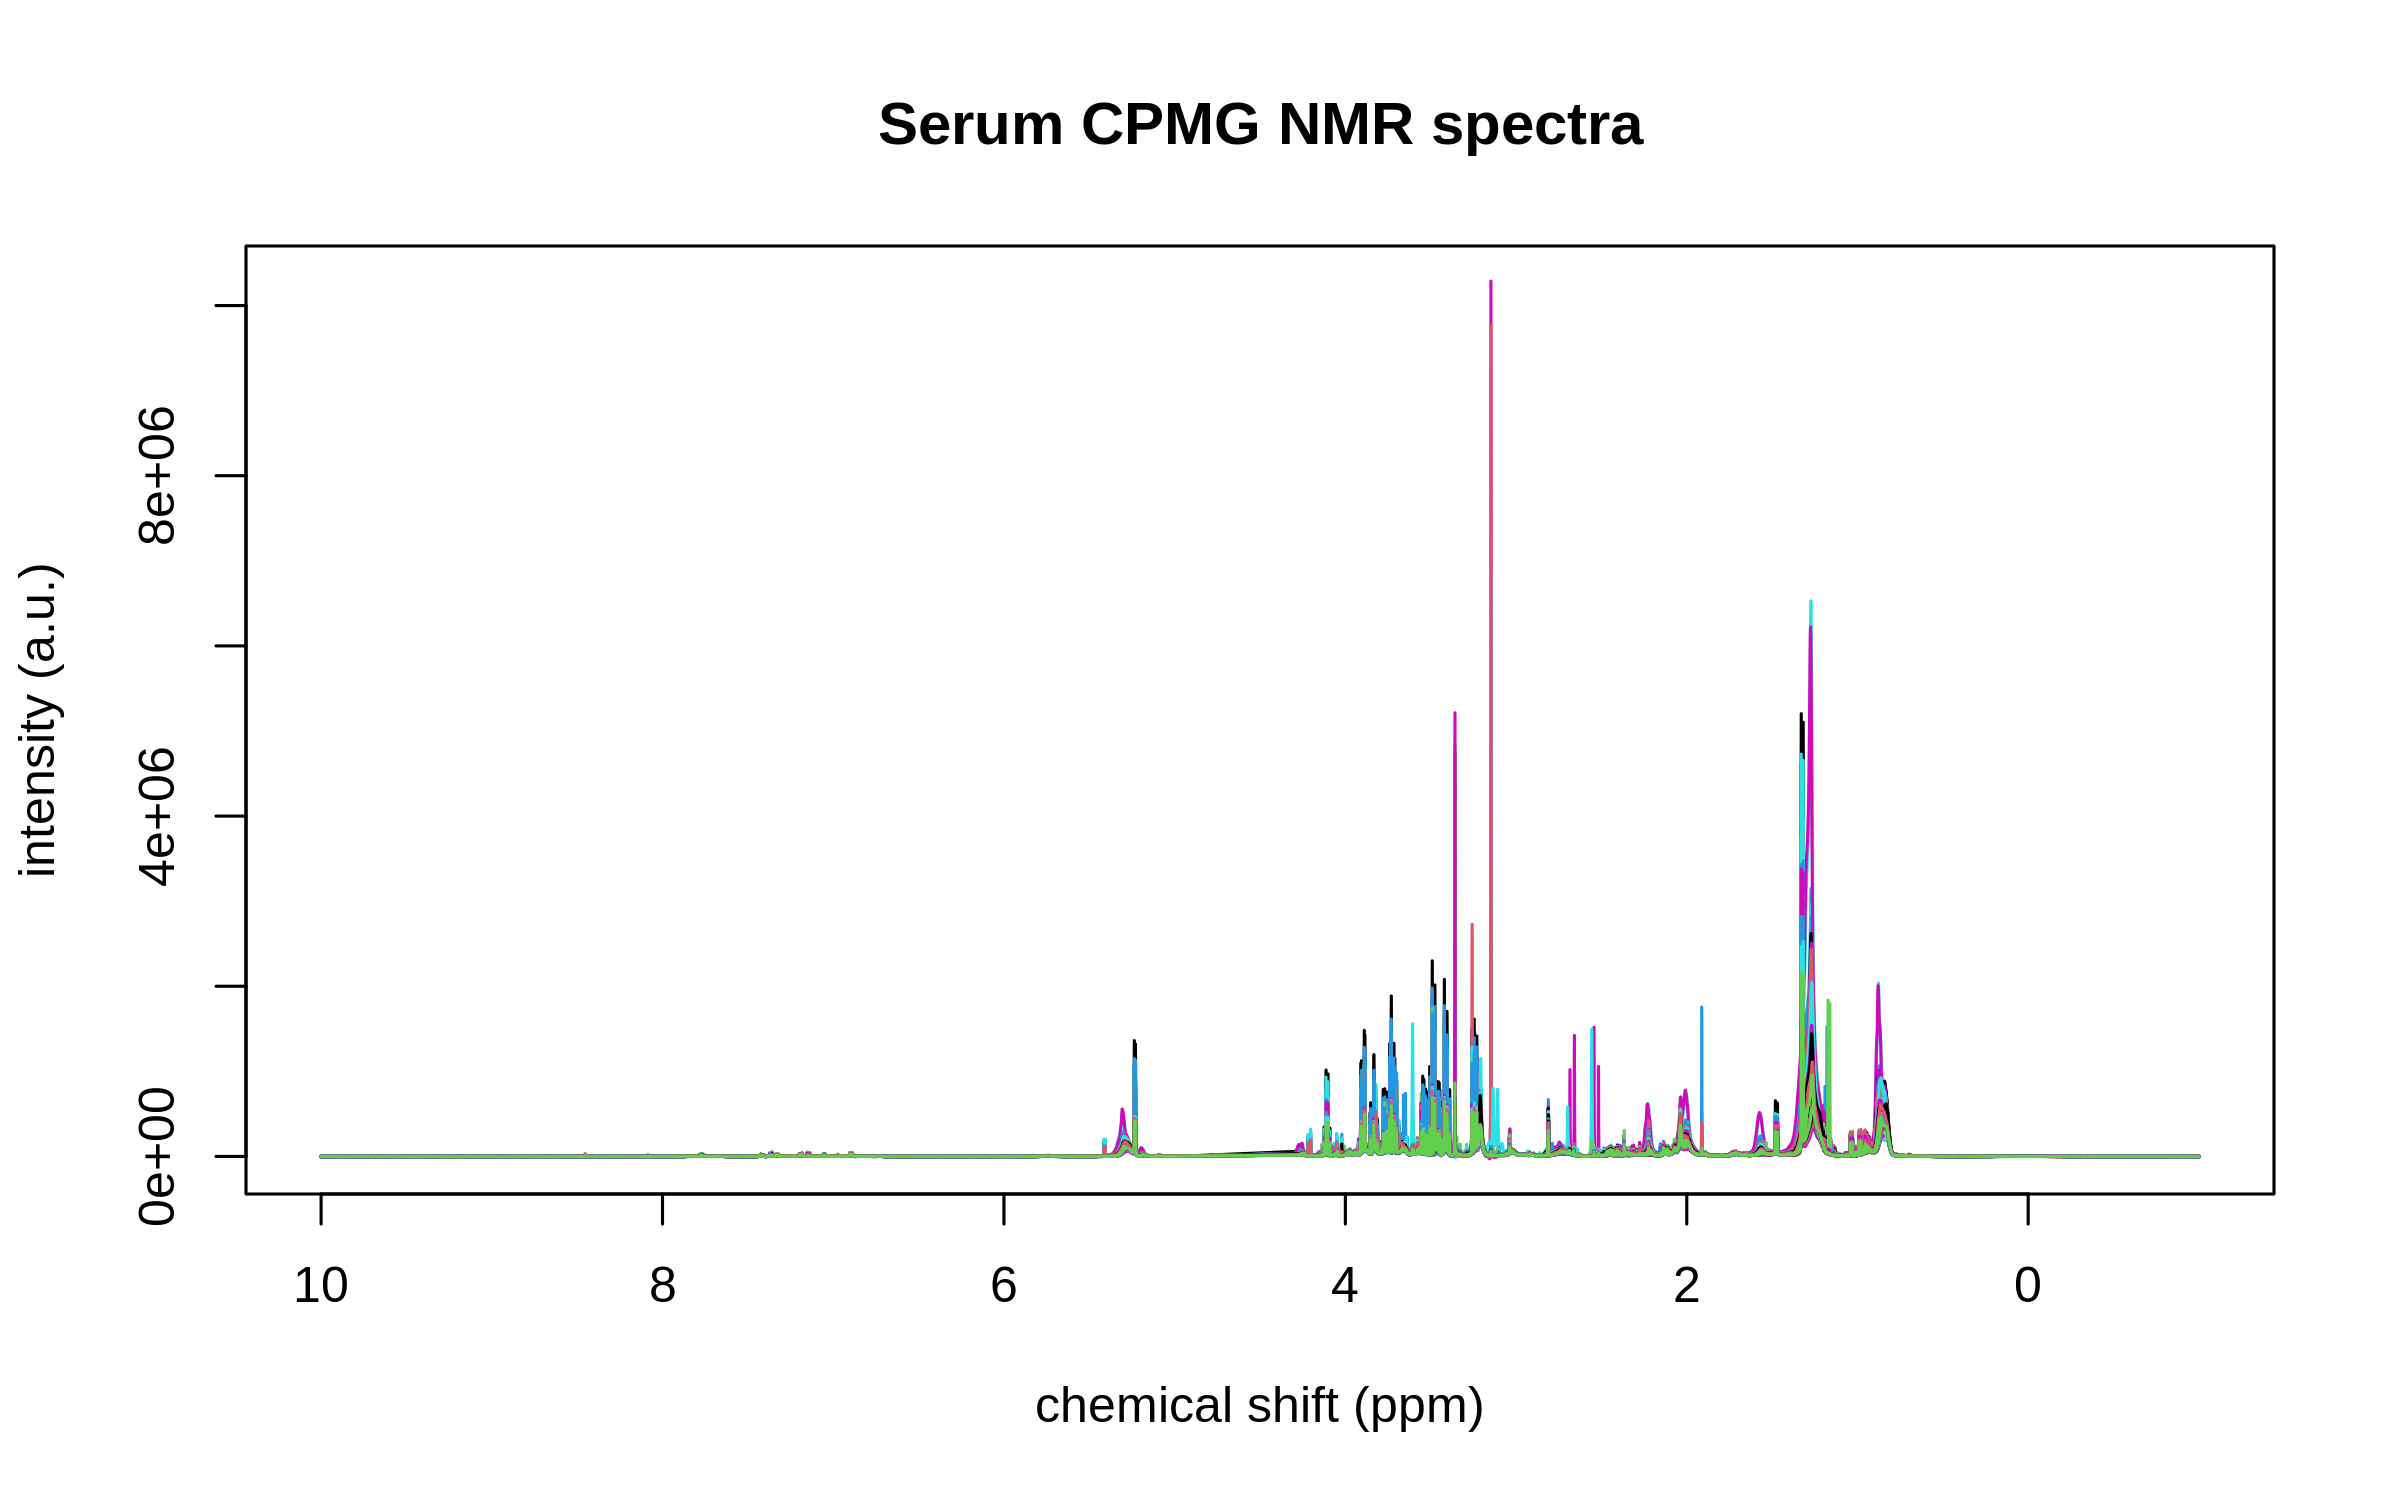

In [22]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 300)
plotNMR(cpmg, ppm=colnames(cpmg), title="Serum CPMG NMR spectra")

*Note: The options function is meant to optimize the size of the image for plotting inside the jupyter notebook. This is not needed to run the code inside RStudio or in any other R instance.*

A zoomed area of the plot about can be easily obtained.  
In the example below, an expansion of the overlaid spectra (0.6-3.0 ppm) is plotted:

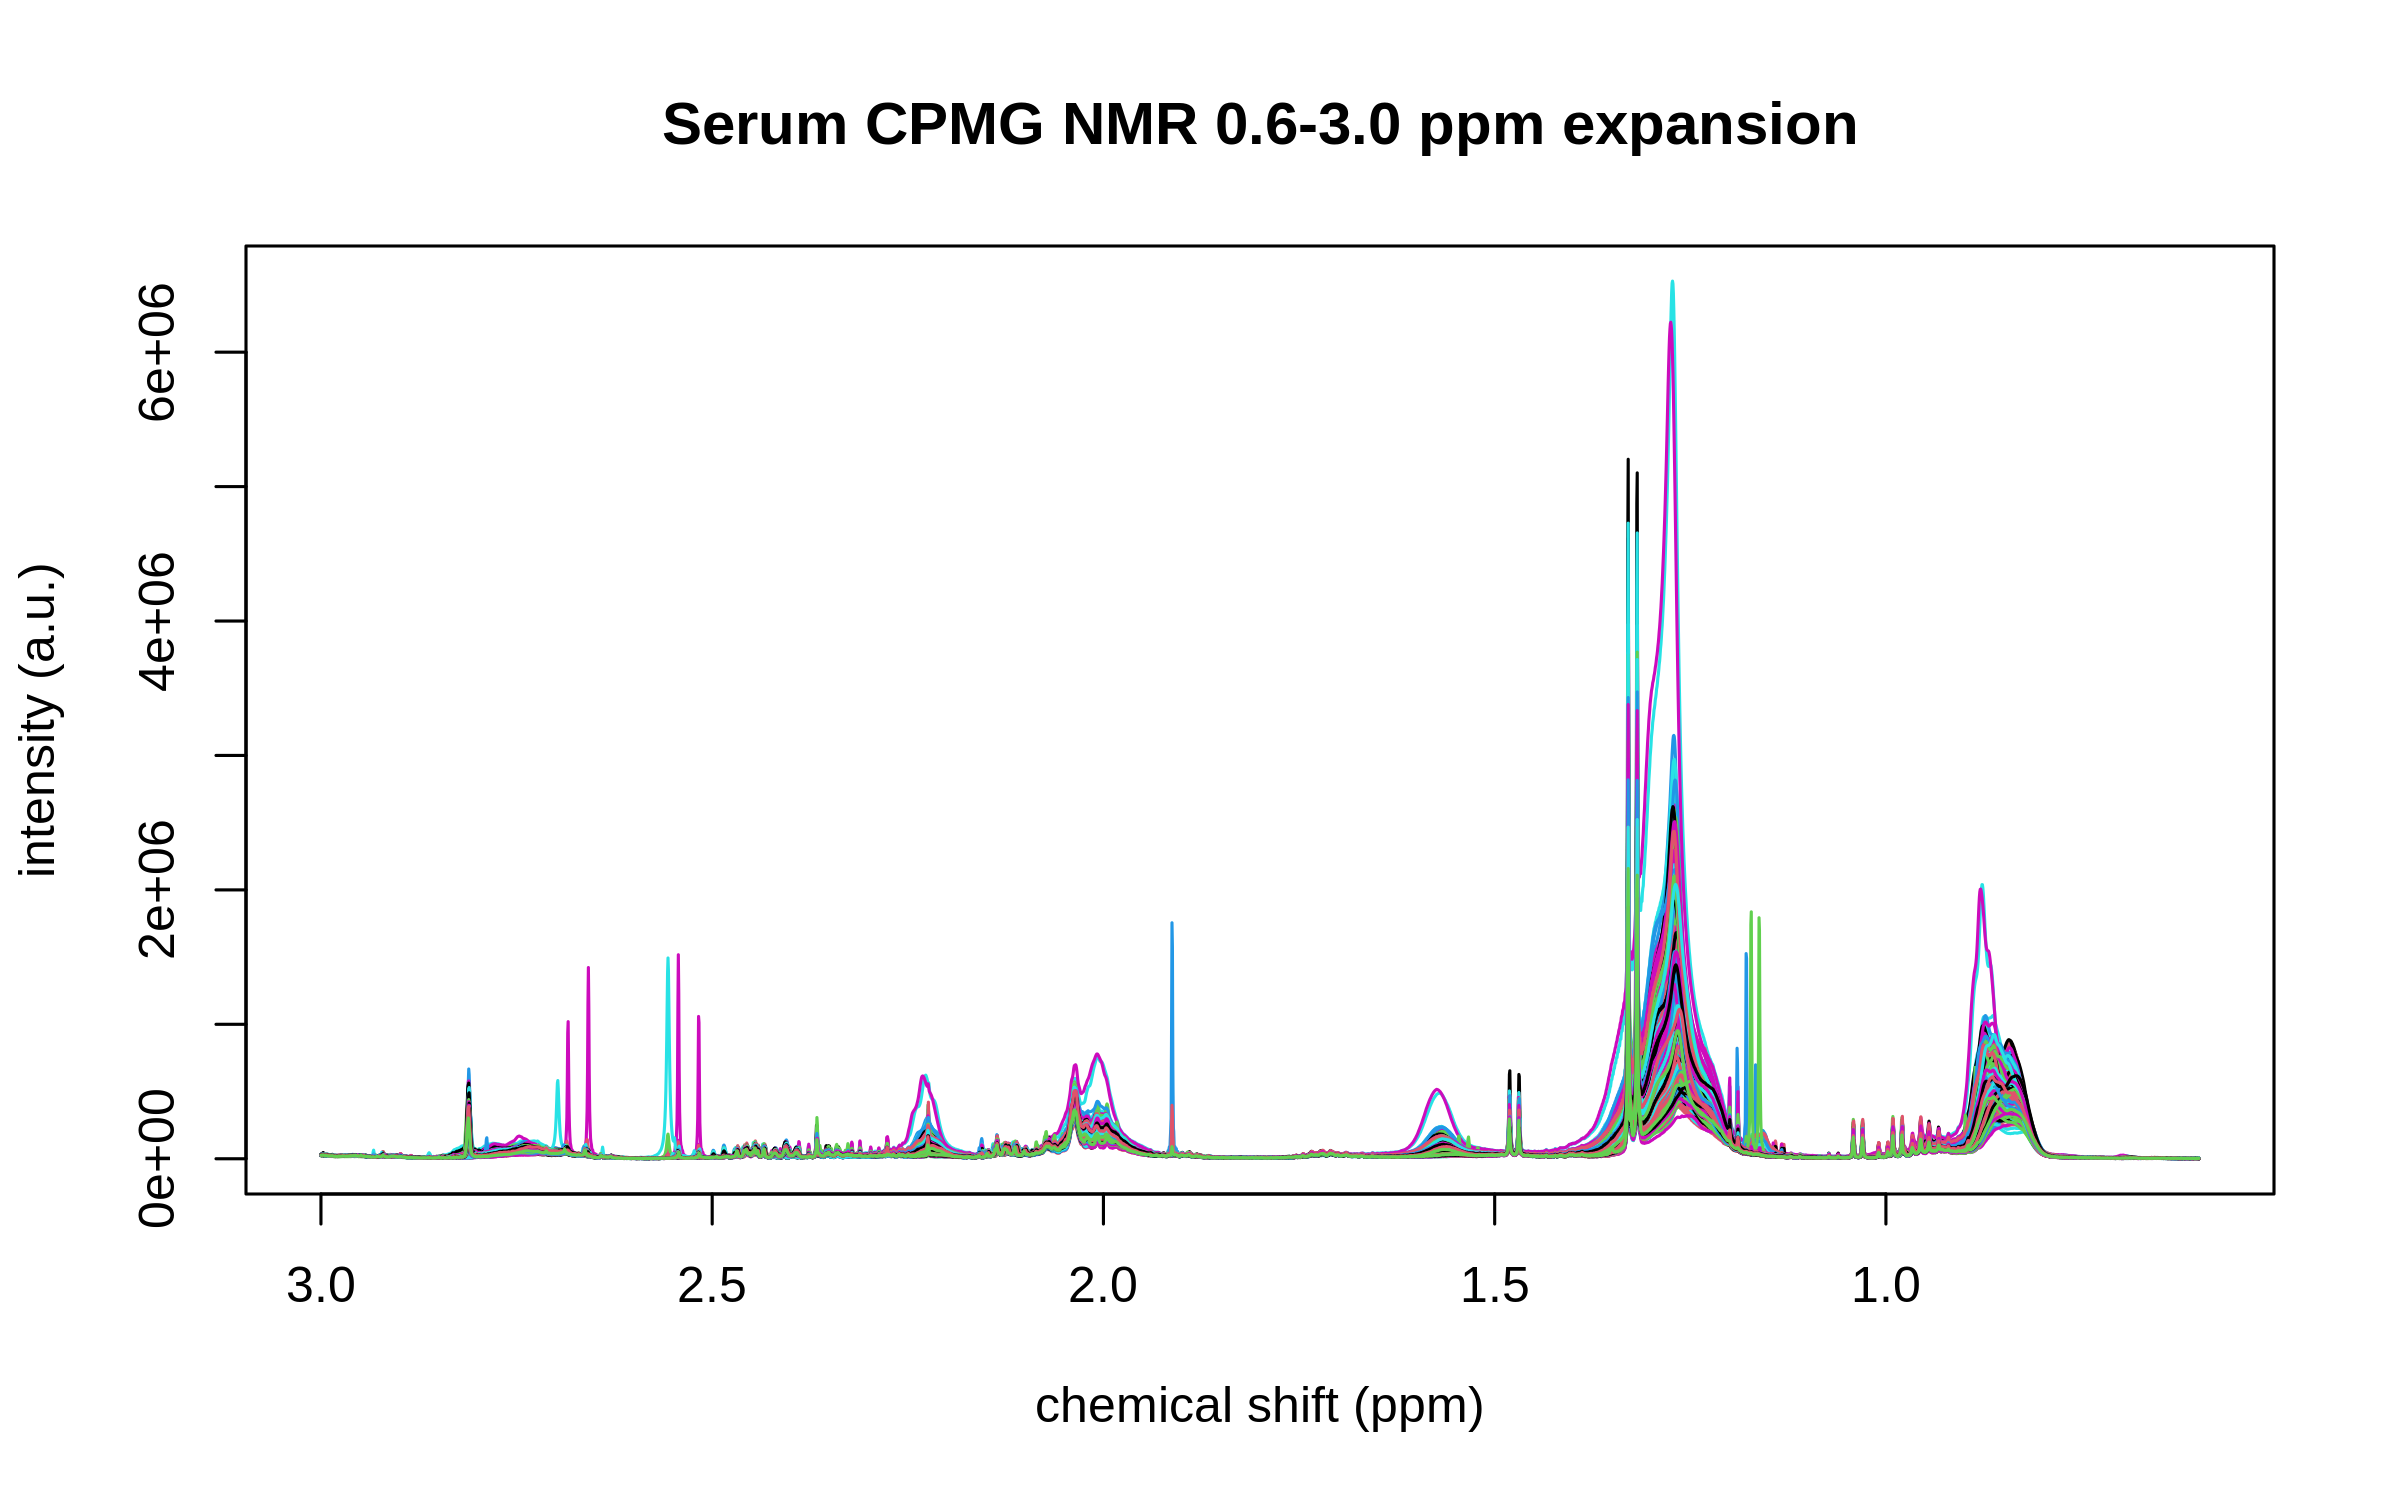

In [23]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 300)
plotNMR(cpmg, 3, 0.6, ppm=colnames(cpmg), title="Serum CPMG NMR 0.6-3.0 ppm expansion")

Each raw LC-MS chromatogram is a 3-dimension dataset composed of m/z, retention time (RT) and intensity dimensions. As the HPOS data is already preprocessed only features (m/z_RT pairs) with their corresponding intensities are present in the data matrix. Therefore, to represent the data as 2D plot, firstly the data is organized by calculating the mean intensity per feature, which is then plotted:

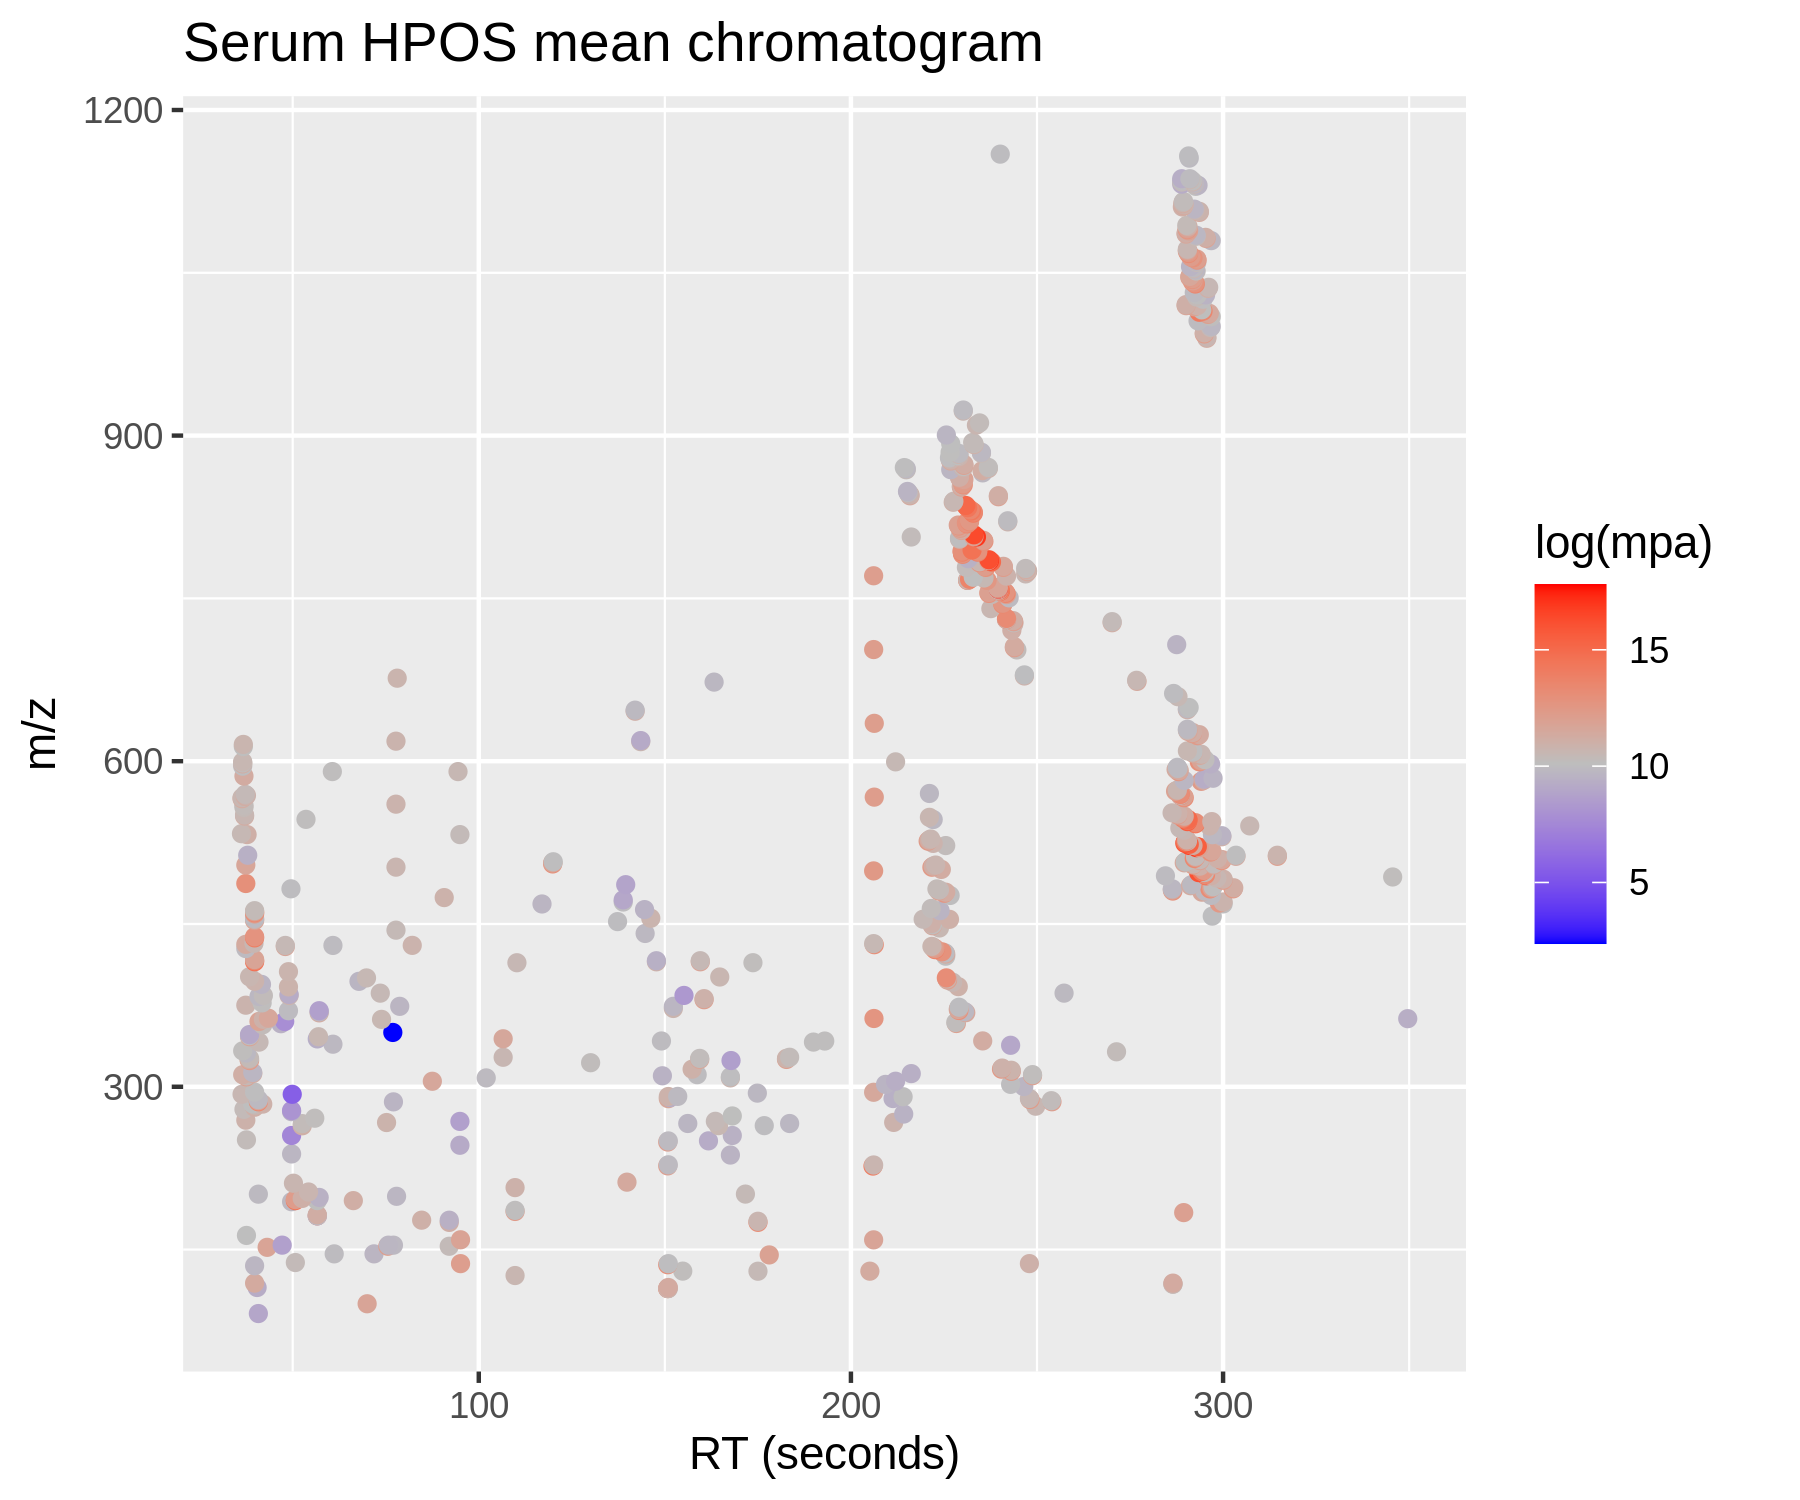

In [24]:
# Organise the LC-MS data first as a data frame of m/z, RT and mean peak intensity
tmp <-  strsplit(colnames(hpos), "_")
rt <- lapply(seq_len(ncol(hpos)), function(x) tmp[[x]][1])
rt <- unlist(rt)
mz <- lapply(seq_len(ncol(hpos)), function(x) tmp[[x]][2])
mz <- unlist(mz)
mz <- gsub("m.z", "", mz)

df <- data.frame(rt=as.numeric(rt), mz=as.numeric(mz), mpa=colMeans(hpos))

# Plot the data
options(repr.plot.width = 6, repr.plot.height = 5, repr.plot.res = 300)
ggplot(df, aes(rt, mz, col=log(mpa))) + geom_point() +
    xlab("RT (seconds)") + ylab("m/z") +
    scale_color_gradientn(colors=c("blue", "grey", high="red")) +
	ggtitle("Serum HPOS mean chromatogram")

### **2. LC-MS feature annotation using NMR data**

To illustrate the usefulness of 1D SHY analysis for LC-MS feature annotation, we apply it to the HPOS feature “150.77_227.1249m.z”:

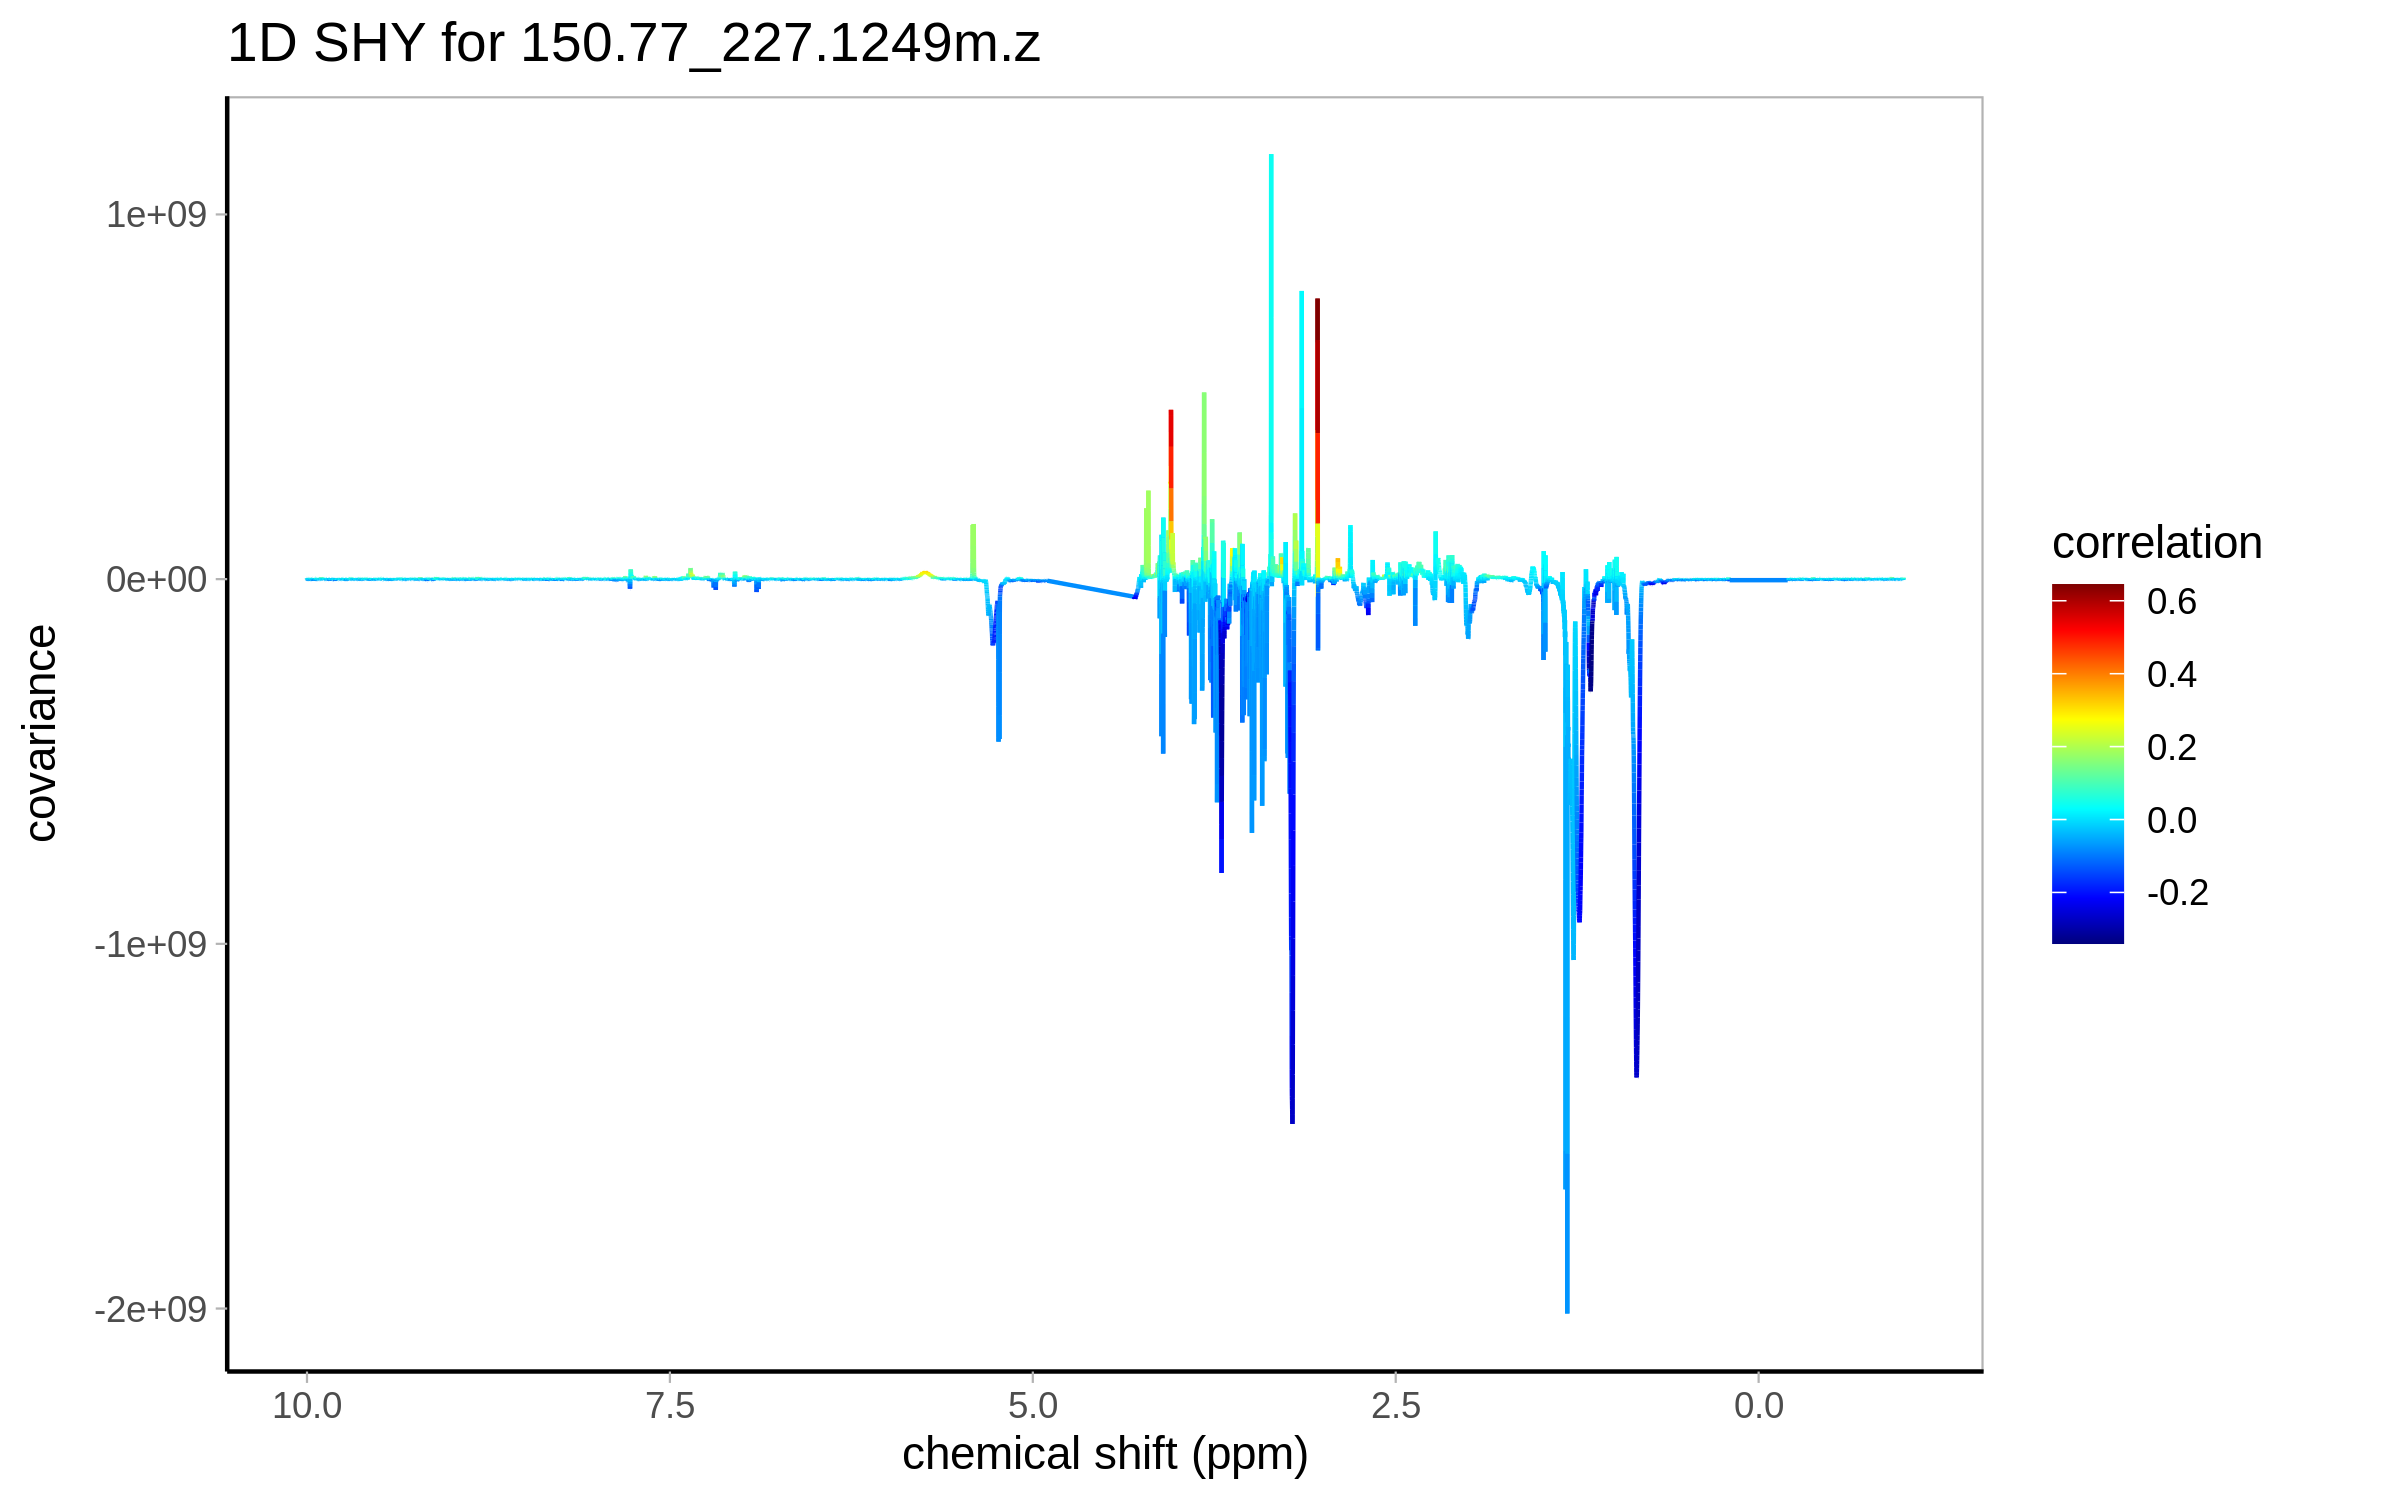

In [25]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 300)
shy1d(cpmg, hpos, YvarName="150.77_227.1249m.z", ppm=NULL, title="1D SHY for 150.77_227.1249m.z")

The two signals highlighted in the plot correspond to the two singlet signals of creatinine at 3.04 and 4.05 ppm. As the neutral monoisotopic mass of creatinine is 113.058911855 Da, it is very likely that this feature corresponds to a [2M+H]+ adduct of creatinine.

Another example of application to the HPOS feature "286.53_119.0888m.z" is shown below:

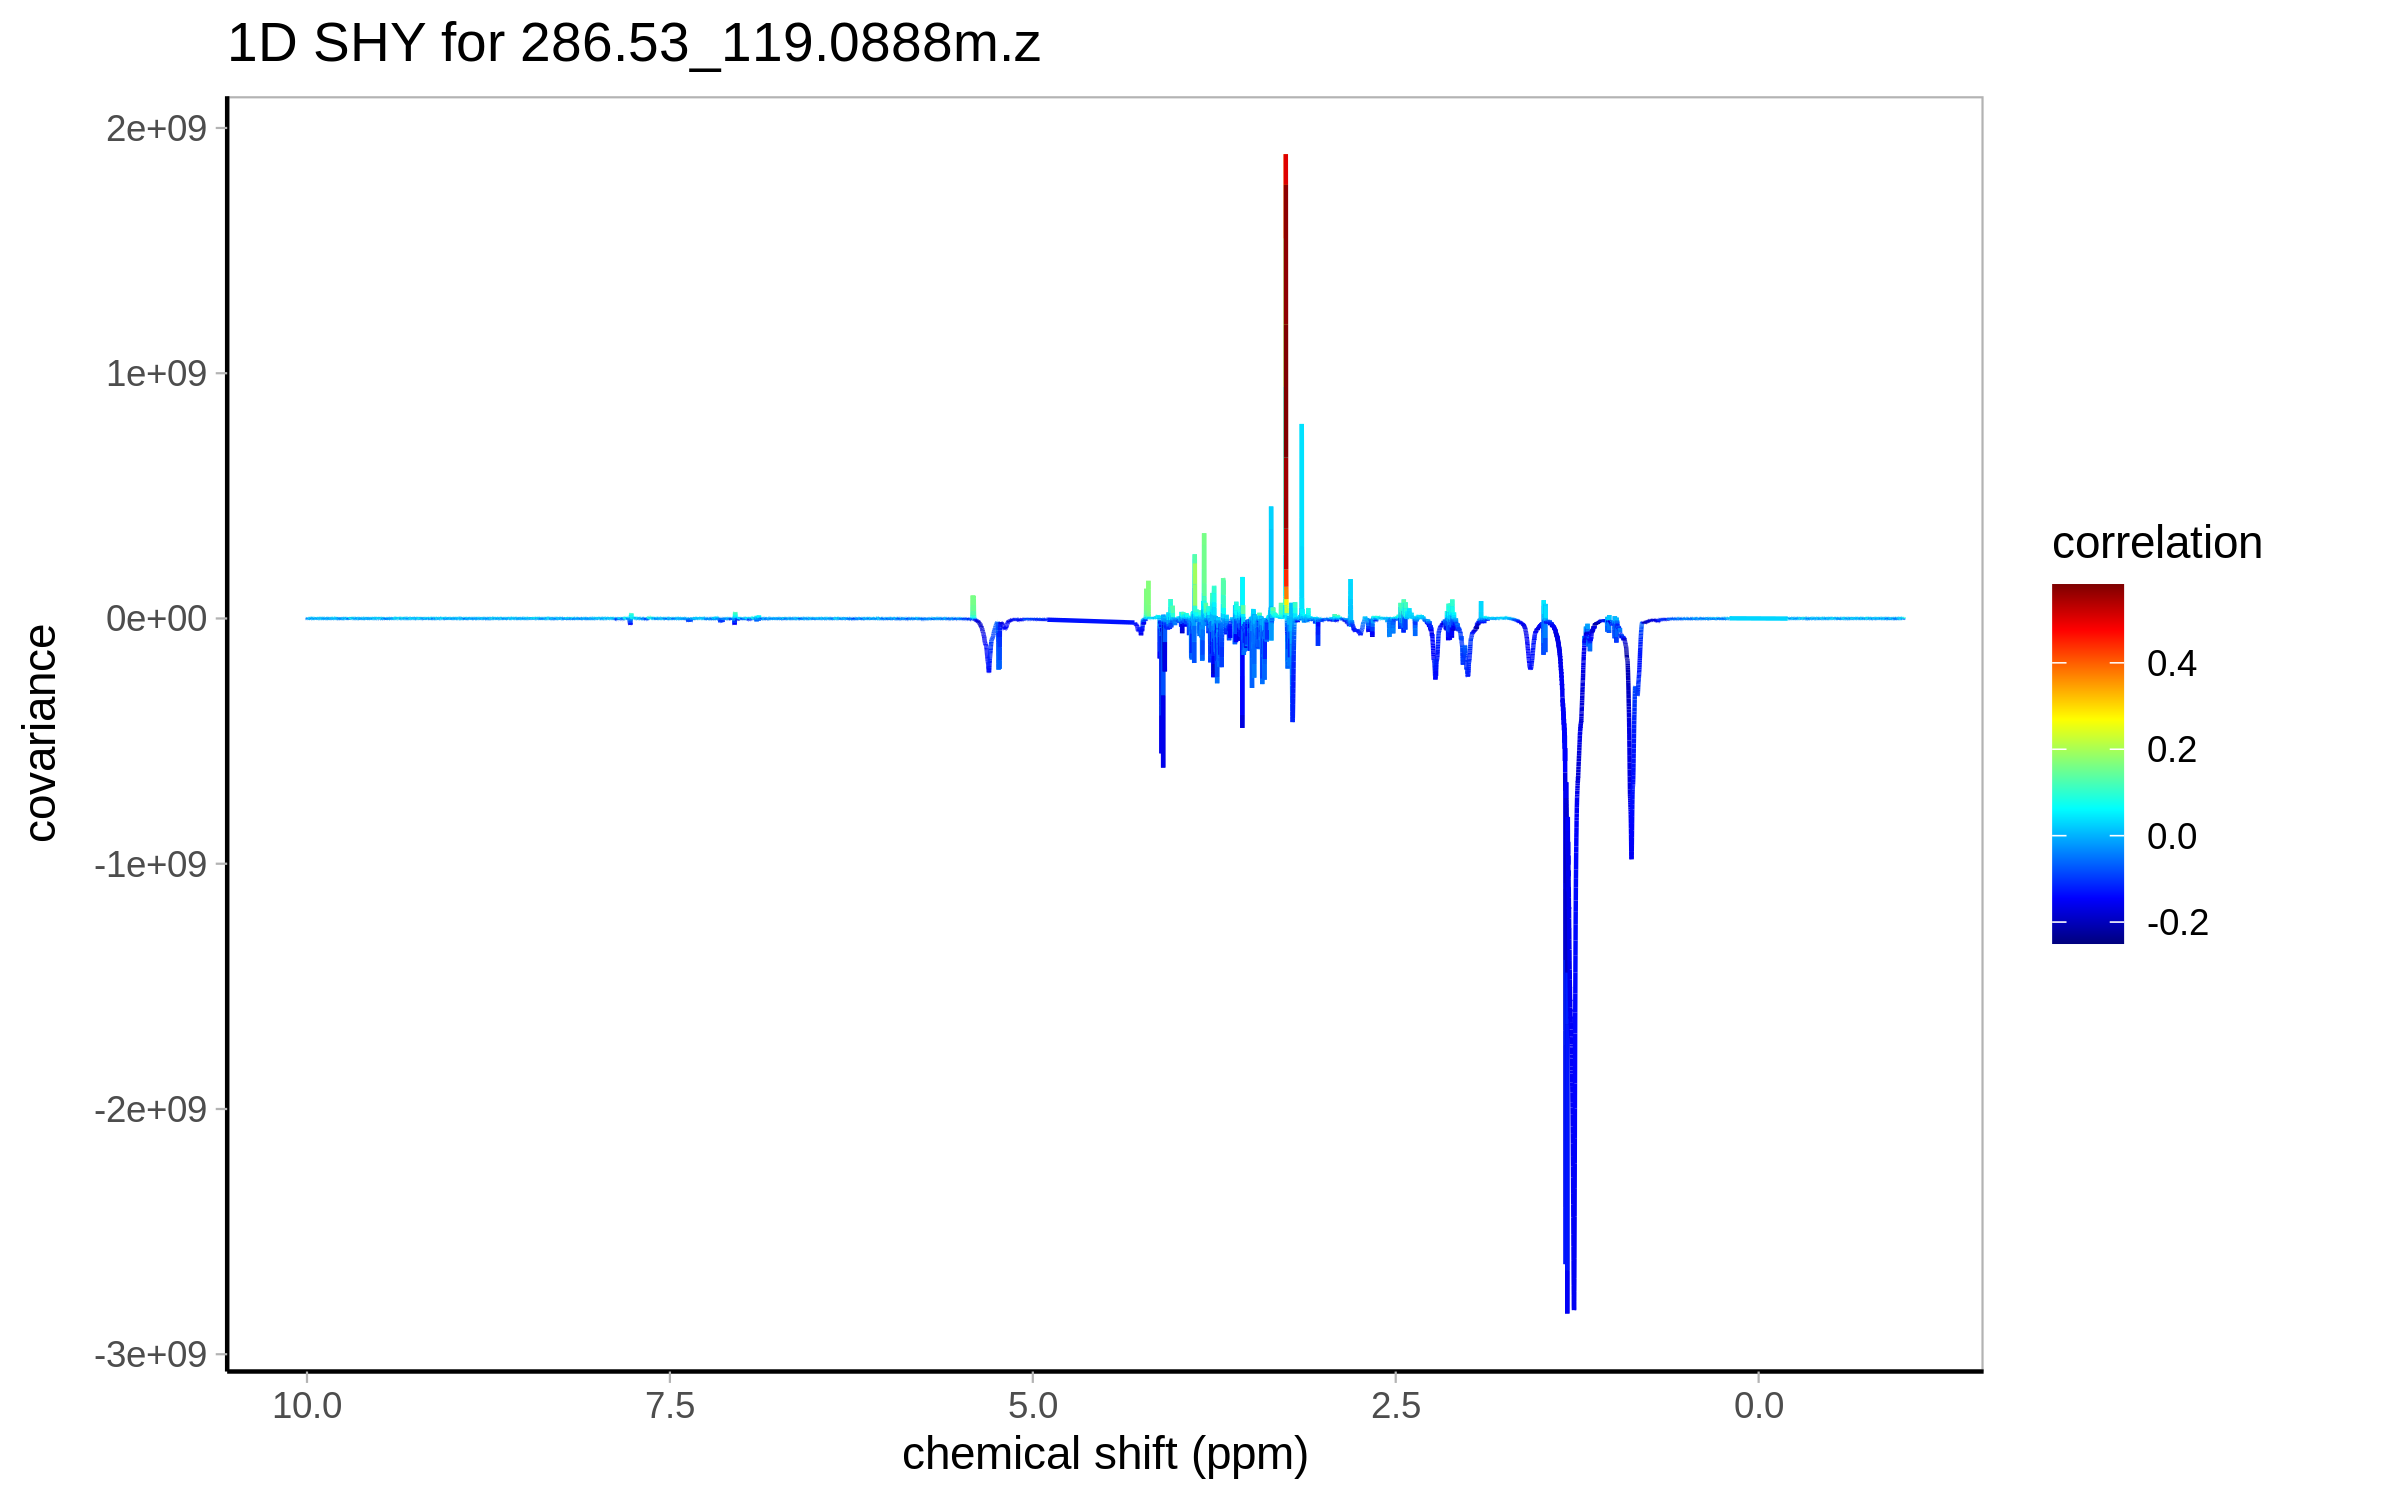

In [26]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 300)
shy1d(cpmg, hpos, YvarName="286.53_119.0888m.z", ppm=NULL, title="1D SHY for 286.53_119.0888m.z")

A single at 3.25 ppm is highlighted in the 1D SHY plot, suggesting the feature could be related to either betaine or TMAO (monoisotopic masses 117.078978594 and 75.068413911 Da, respectively). Since the feature is closer to betaine in terms of mass, it might be in fact correspond to one the isotopes of the betaine proton adduct, [M+1+H]+ (119.0899 m/z).

**Reference**  
Lovestone S (2009) AddNeuroMed─The European Collaboration for the Discovery of Novel Biomarkers for Alzheimer's Disease. Ann NY Acad Sci 1180 (1), 36–46. doi: 10.1111/j.1749-6632.2009.05064.x